# Merge and Export Machine Learning Dataset - Lyon
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Momepy) and merges them into one comprehensive `.csv` table for the Lyon ML models.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_class.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,143403_21714981_0,4,4,3,5,4001.051496,0.0,366.150625,98.073488,0.0,213.549543
1,143403_21718288_0,4,4,3,5,4005.447822,0.0,373.342535,98.501227,0.0,215.068457
2,143403_143408_0,4,4,3,2,3902.900937,0.0,323.583327,98.501227,0.0,215.068457
3,143408_21718264_0,3,3,1,5,3812.886444,0.0,323.583327,0.000000,0.0,293.111426
4,143408_932576340_0,4,4,3,2,3809.626885,0.0,274.800044,108.501123,0.0,293.111426


In [4]:
df_momepy_roads.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,143403_21714981_0,50.000000,1.000000,0.000286,0.000199,0.000028,0.849272
1,143403_21718288_0,27.036067,0.700000,0.000582,0.000198,0.000027,0.845655
2,143403_143408_0,31.248798,0.500000,0.007972,0.000200,0.000026,0.848310
3,143408_21718264_0,20.502936,0.355263,0.001119,0.000204,0.000024,0.841243
4,143408_932576340_0,33.348257,0.409091,0.008019,0.000204,0.000023,0.846601


In [5]:
# Drop non-ML columns from momepy (openness and height are morphological intermediates)
df_momepy_roads.drop(['openness'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betweenness,closeness_global,closeness_400,straightness
0,143403_21714981_0,50.000000,0.000286,0.000199,0.000028,0.849272
1,143403_21718288_0,27.036067,0.000582,0.000198,0.000027,0.845655
2,143403_143408_0,31.248798,0.007972,0.000200,0.000026,0.848310
3,143408_21718264_0,20.502936,0.001119,0.000204,0.000024,0.841243
4,143408_932576340_0,33.348257,0.008019,0.000204,0.000023,0.846601


In [6]:
df_osm_points.head()

,road_id,signals,transport,pois
0,143403_21714981_0,0.142277,0.000000,0.000000
1,143403_21718288_0,0.142277,0.000000,0.000000
2,143403_143408_0,0.078092,0.000000,0.000000
3,143408_21718264_0,0.012924,0.000000,0.003231
4,143408_932576340_0,0.085854,0.010732,0.000000


In [7]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,143403_21714981_0,0.000000,0.0,0.0
1,143403_21718288_0,0.000000,0.0,0.0
2,143403_143408_0,0.000000,0.0,0.0
3,143408_21718264_0,0.662297,0.0,0.0
4,143408_932576340_0,0.000000,0.0,0.0


## Merge dataframes

In [8]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [9]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betweenness,closeness_global,closeness_400,straightness,green,industrial,commercial
0,143403_21714981_0,4,4,3,5,4001.051496,0.0,366.150625,98.073488,0.0,...,0.000000,0.000000,50.000000,0.000286,0.000199,0.000028,0.849272,0.000000,0.0,0.0
1,143403_21718288_0,4,4,3,5,4005.447822,0.0,373.342535,98.501227,0.0,...,0.000000,0.000000,27.036067,0.000582,0.000198,0.000027,0.845655,0.000000,0.0,0.0
2,143403_143408_0,4,4,3,2,3902.900937,0.0,323.583327,98.501227,0.0,...,0.000000,0.000000,31.248798,0.007972,0.000200,0.000026,0.848310,0.000000,0.0,0.0
3,143408_21718264_0,3,3,1,5,3812.886444,0.0,323.583327,0.000000,0.0,...,0.000000,0.003231,20.502936,0.001119,0.000204,0.000024,0.841243,0.662297,0.0,0.0
4,143408_932576340_0,4,4,3,2,3809.626885,0.0,274.800044,108.501123,0.0,...,0.010732,0.000000,33.348257,0.008019,0.000204,0.000023,0.846601,0.000000,0.0,0.0
5,143412_8752289484_0,3,3,2,5,2746.383163,0.0,132.490232,230.522987,0.0,...,0.050604,0.050450,30.389880,0.002790,0.000240,0.000033,0.838309,1.858992,0.0,0.0
6,143412_8752289487_0,4,4,2,2,2750.137307,0.0,149.924435,215.264085,0.0,...,0.050604,0.065350,42.729322,0.022958,0.000241,0.000034,0.839445,1.532913,0.0,0.0
7,143413_21852320_0,2,2,1,5,2920.512386,0.0,254.172677,57.972571,0.0,...,0.000000,0.024954,15.221893,0.000132,0.000236,0.000031,0.836792,0.000000,0.0,0.0
8,143413_8168938341_0,4,4,3,2,2923.210446,0.0,254.172677,0.000000,0.0,...,0.034516,0.051774,22.287223,0.025242,0.000234,0.000036,0.843744,0.000000,0.0,0.0
9,143415_143435_0,4,4,3,2,2676.470061,0.0,292.932117,264.466441,0.0,...,0.026342,0.013171,30.182800,0.044517,0.000247,0.000032,0.829991,0.000000,0.0,0.0


<class 'pandas.DataFrame'>
RangeIndex: 7159 entries, 0 to 7158
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                7159 non-null   str    
 1   noise_day              7159 non-null   int64  
 2   noise_evening          7159 non-null   int64  
 3   noise_night            7159 non-null   int64  
 4   road_category          7159 non-null   int64  
 5   dist_to_trunk          7159 non-null   float64
 6   dist_to_primary        7159 non-null   float64
 7   dist_to_secondary      7159 non-null   float64
 8   dist_to_tertiary       7159 non-null   float64
 9   dist_to_residential    7159 non-null   float64
 10  dist_to_living_street  7159 non-null   float64
 11  signals                7159 non-null   float64
 12  transport              7159 non-null   float64
 13  pois                   7159 non-null   float64
 14  width                  7159 non-null   float64
 15  betweenness    

## Noise distribution

      Day  Evening  Night
0     NaN      NaN    101
1   102.0    102.0   1937
2  1685.0   1685.0   3320
3  3443.0   3443.0   1778
4  1929.0   1929.0     23


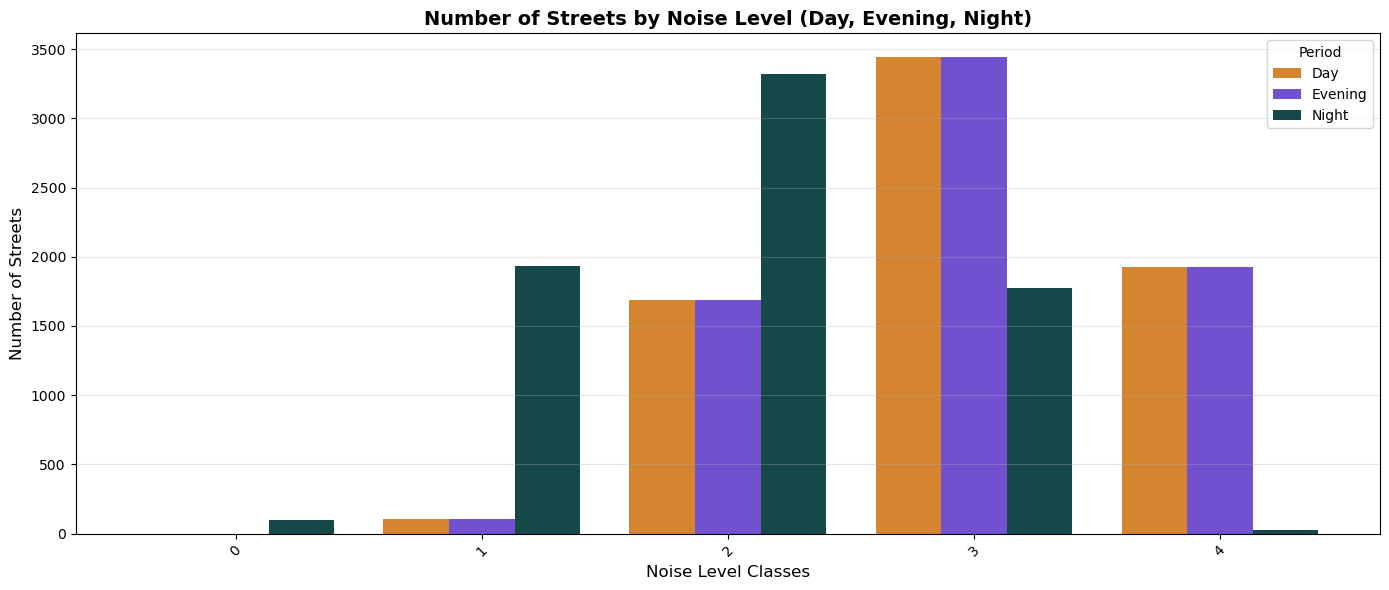

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_day     = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night   = ml_dataset.groupby('noise_night').size()

comparison_df = pd.DataFrame({'Day': counts_day, 'Evening': counts_evening, 'Night': counts_night})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(
    kind='bar', ax=ax, width=0.8, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for scikit-learn in the next phase.

In [11]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "lyo_noise_class_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\lyo_noise_class_ml_dataset.csv


## Subsample
Stratified subsample of 5000 segments preserving noise_day class distribution.

In [12]:
sample_size = 5000

proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
1    0.0142
2    0.2354
3    0.4810
4    0.2694
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
1             102     71
2            1685   1177
3            3443   2405
4            1929   1347


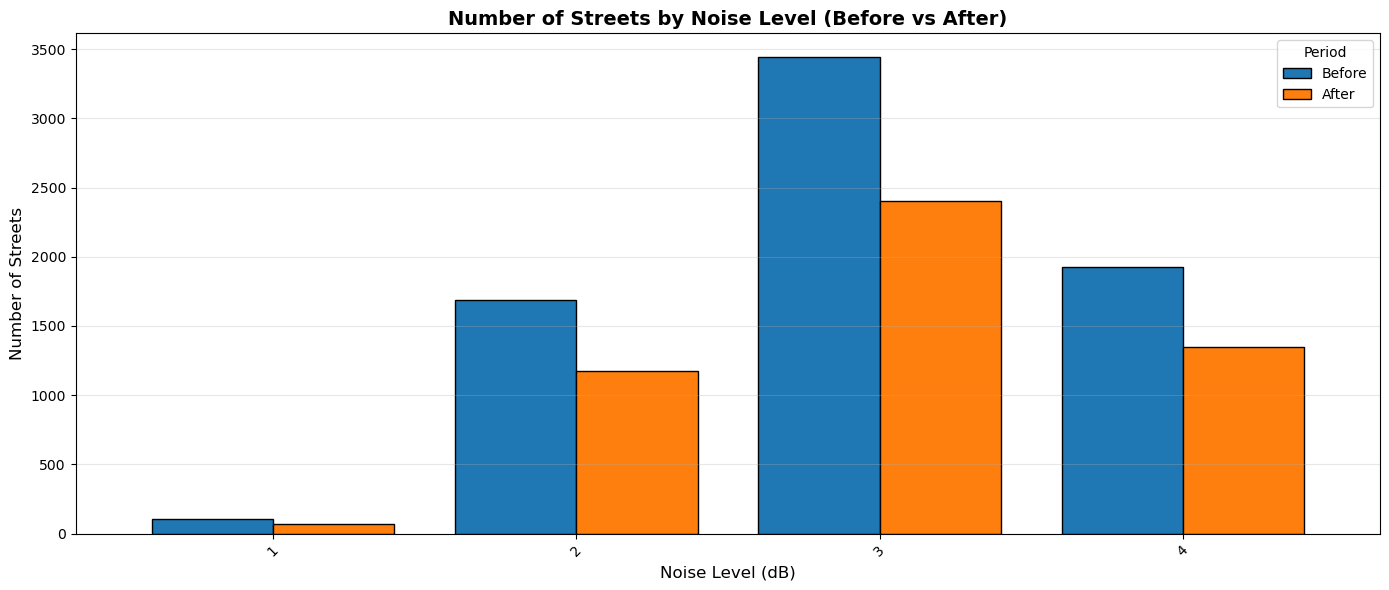

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_before = ml_dataset.groupby('noise_day').size()
counts_after  = subsampled.groupby('noise_day').size()

comparison_df = pd.DataFrame({'Before': counts_before, 'After': counts_after})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [14]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "lyo_noise_class_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\lyo_noise_class_ml_subsample.csv
